In [3]:
kvmer_results = {
    "K12_MG1655_isolates": [0.9684175302882675, 0.9689322953718571, 0.9689115910258965, 0.9695486971865291, 0.9709146532088786, 0.9709863268896837, 0.9717182244540243, 0.9717726209048362, 0.9687578387598454, 0.9744177315156458],
    "O157_H7_isolates": [0.9685194493538501, 0.9691871123276663, 0.969390751584875, 0.9699388798802545, 0.9692919606114051, 0.970005970375565, 0.9711594825901755, 0.9707255241237777, 0.9677700167886086, 0.9742568320054827],
    "Mixture": [0.9650327997204393, 0.9654571790029519, 0.9662485519494084, 0.9669809698357401, 0.9666410906559485, 0.9674295867195138, 0.9690009671915583, 0.9687887267079004, 0.9651148656861553, 0.9712906321218664]
}

kvmer_results_filtered = {
    "K12_MG1655_isolates": [0.9696364281730135, 0.9697628933909278, 0.9699633304572908, 0.9705787513203981, 0.9716344556587886, 0.9718439390187825, 0.9727024567788899, 0.9723230433426878, 0.9688413977115296, 0.9749493558594939],
    "O157_H7_isolates": [0.9699578723439894, 0.9698649535454011, 0.9706379872153273, 0.9705019078368066, 0.970730001512173, 0.9707918333966177, 0.9719890483497308, 0.9713572298231494, 0.9682607125406301, 0.9754042609210786],
    "Mixture": [0.9699966997340373, 0.9703495411834165, 0.9704541704479829, 0.9715311945421506, 0.9710469898494924, 0.9715016276738344, 0.9731700812781894, 0.9728354759153134, 0.9707665364407921, 0.9754245199707314]
}

In [2]:
kvmer_results = {
    "compare_strains": [0.9699966997340373, 0.9703495411834165, 0.9704541704479829, 0.9715311945421506, 0.9710469898494924, 0.9715016276738344, 0.9731700812781894, 0.9728354759153134, 0.9707665364407921, 0.9754245199707314]
}

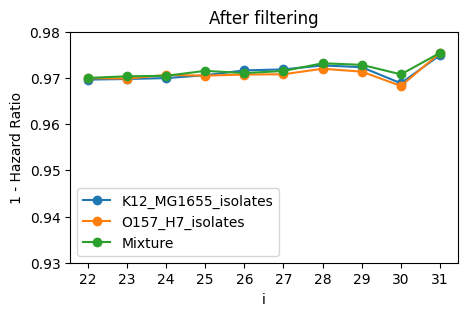

In [4]:
# Plot the change of hazard ratio with different k

import matplotlib.pyplot as plt
import numpy as np

k = 21
x = k + np.arange(1, 11)
data = kvmer_results_filtered
plt.figure(figsize=(5, 3))
plt.plot(x, data["K12_MG1655_isolates"], marker='o', label='K12_MG1655_isolates')
plt.plot(x, data["O157_H7_isolates"], marker='o', label='O157_H7_isolates')
plt.plot(x, data["Mixture"], marker='o', label='Mixture')

# Also plot a horizontal line at y=0.95 for reference
#plt.axhline(y=0.96, color='r', linestyle='--', label='Ground truth read identity')

plt.title(f'After filtering')
plt.xlabel('i')
plt.ylabel('1 - Hazard Ratio')
plt.ylim(0.93, 0.98)
plt.xticks(x)
plt.legend()

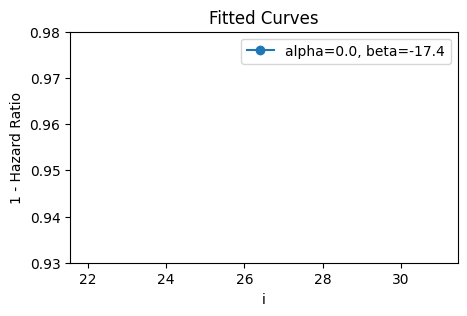

Fitted parameters for compare_strains: alpha = 0.040115, beta = -17.354606


In [18]:
from scipy.optimize import curve_fit

num_trim_values = 0
x = k + np.arange(1, 11)
# Define the function to fit
def fit_function(i, alpha, beta):
    return 1 - alpha / (alpha + beta + i)

# Fit the curves
data = kvmer_results
fit_params = {}
for key, values in data.items():
    i_values = x  # x is already defined as k + np.arange(1, 11)
    popt, _ = curve_fit(fit_function, i_values, values, p0=[1, 1])  # Initial guess for alpha and beta
    fit_params[key] = popt  # Store the fitted parameters

# Print the fitted parameters
# Plot the fitted curves
plt.figure(figsize=(5, 3))
i = 0
for key, values in data.items():
    i_values = x
    fitted_curve = fit_function(i_values, *fit_params[key])
    plt.plot(i_values, fitted_curve, linestyle='--', color=f'C{i}')
    plt.plot(i_values, values, marker='o', label=f'alpha={fit_params[key][0]:.1f}, beta={fit_params[key][1]:.1f}', color=f'C{i}')
    i += 1

plt.title('Fitted Curves')
plt.xlabel('i')
plt.ylabel('1 - Hazard Ratio')
plt.legend()
plt.ylim(0.93, 0.98)
plt.show()

for key, params in fit_params.items():
    alpha, beta = params
    print(f"Fitted parameters for {key}: alpha = {alpha:.6f}, beta = {beta:.6f}")

In [11]:
for key, params in fit_params.items():
    alpha, beta = params
    print(f"Fitted parameters for {key}: mean = {alpha / (alpha + beta)}, variance = {alpha * beta / ((alpha + beta)**2 * (alpha + beta + 1))}")

Fitted parameters for K12_MG1655_isolates: mean = 0.03575891311272336, variance = 0.00041468721742446267
Fitted parameters for O157_H7_isolates: mean = 0.03275609592990061, variance = 0.0002511243658944662
Fitted parameters for Mixture: mean = 0.03666275655140833, variance = 0.00039910022147368813


In [14]:
for key, params in fit_params.items():
    alpha, beta = params
    print(f"Fitted parameters for {key}: mean = {alpha / (alpha + beta)}, variance = {alpha * beta / ((alpha + beta)**2 * (alpha + beta + 1))}")

Fitted parameters for K12_MG1655_isolates: mean = 0.04906497546813436, variance = 0.0011385300622229273
Fitted parameters for O157_H7_isolates: mean = 0.041479108669424204, variance = 0.0005693820349338876
Fitted parameters for Mixture: mean = 0.05108671881477801, variance = 0.001002891201602386


In [30]:
import pandas as pd
import glob

output_dir="../../output/multiple_alleles"
prefix = "Ecoli_K12_MG1655"

id = [100, 98, 96, 94, 92, 90]
ratio = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Initialize list to store results as a df
identity = []
ratio_list = []
lambda_estimates = []
beta_estimates = []
with_filter = []

for i in id:
    for r in ratio:

        #print(f"Processing identity {i} and ratio {r}")
        lambda_list = []
        b_list = []
        coverage_list = []
        
        output_file_name = f"{output_dir}/{prefix}_ratio_{r}_id_{i}_exp_[0-9+]_bi.csv"
        output_file_no_filter_name = f"{output_dir}/{prefix}_ratio_{r}_id_{i}_exp_[0-9+]_bi_no_filter.csv"
        all_files = glob.glob(output_file_name)
        for file in all_files:
            df = pd.read_csv(file)


            lambda_estimates.append(df['lambda'].item())
            beta_estimates.append(df['beta'].item())
            identity.append(i)
            ratio_list.append(r)
            with_filter.append('With filter')
        
        all_files = glob.glob(output_file_no_filter_name)
        for file in all_files:
            df = pd.read_csv(file)

            lambda_estimates.append(df['lambda'].item())
            beta_estimates.append(df['beta'].item())
            identity.append(i)
            ratio_list.append(r)
            with_filter.append('Without filter')


In [31]:
import numpy as np

result_df = pd.DataFrame({
    'identity': identity,
    'ratio': ratio_list,
    'lambda_estimate': lambda_estimates,
    'beta_estimate': beta_estimates,
    'with_filter': with_filter
})
result_df['error_estimate'] = 1 - np.exp(-result_df['lambda_estimate'])

<>:67: SyntaxWarning: invalid escape sequence '\h'
<>:67: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_57506/4061945694.py:67: SyntaxWarning: invalid escape sequence '\h'
  math_label = '$\hat{S}(t) = e^{-%.4ft^{%.4f}}$' % (l, bet)
/tmp/ipykernel_57506/4061945694.py:61: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
/tmp/ipykernel_57506/4061945694.py:61: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
/tmp/ipykernel_57506/4061945694.py:61: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
/tmp/ipykernel_57506/4061945694.py:61: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_esti

Fitted parameters: alpha = 1.000000, beta = 1.000000
Fitted parameters: alpha = 0.979604, beta = 1.000000
Fitted parameters: alpha = 0.958976, beta = 1.000000
Fitted parameters: alpha = 0.937759, beta = 1.000000
Fitted parameters: alpha = 0.915997, beta = 1.000000
Fitted parameters: alpha = 0.893522, beta = 1.000000


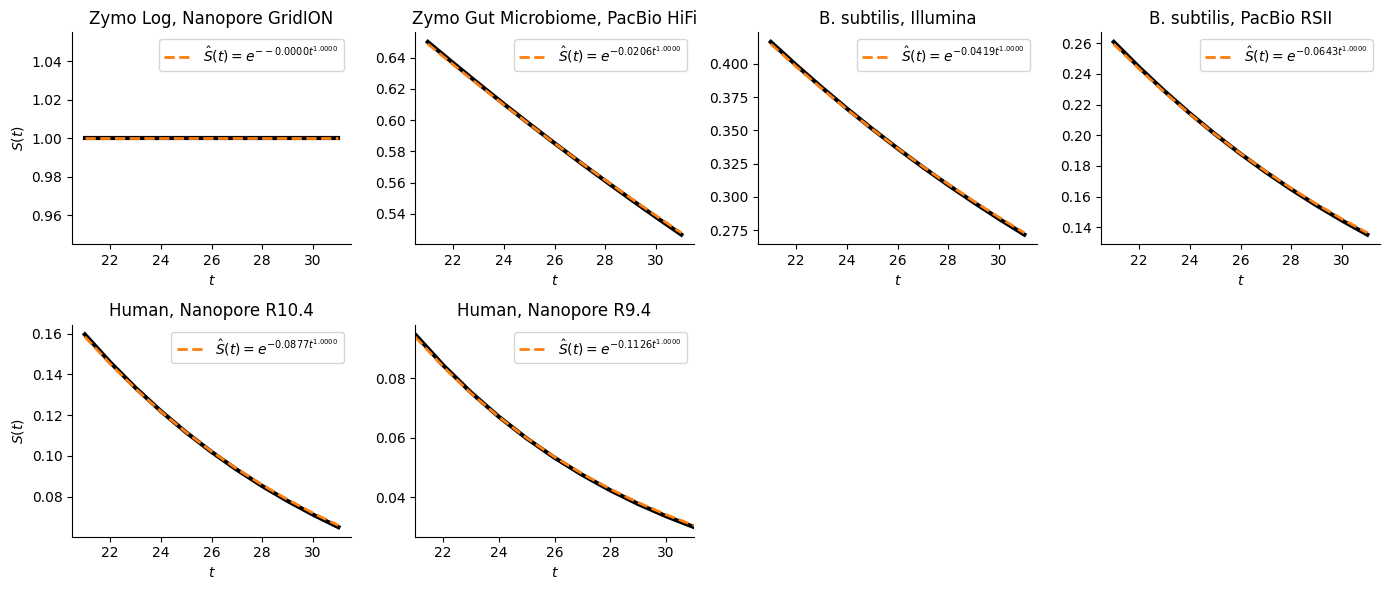

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns


# Define the function to fit
def fit_function_constant(i, alpha, beta):
    return np.exp(- alpha - beta * i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean * i + (std ** 2) * (i ** 2) / 2)

def fit_function_discrete_weibull(i, l, k):
    return l ** ((i) ** 1)


kmer_hit_rate_csv = [
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_100.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_98.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_96.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_94.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_92.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_90.matched_kmers.csv",
]

labels = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut Microbiome, PacBio HiFi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII",
    "Human, Nanopore R10.4",
    "Human, Nanopore R9.4",
    "Human, PacBio HiFi"
]

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
hazard_ratio_plot_range = range(21, 32)
hazard_ratio_estimate_range = range(21, 32)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

ground_truth_lambda = []

func = fit_function_discrete_weibull
#func = fit_function_constant

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values

    
    survival_rates_esimates = survival_rates[hazard_ratio_estimate_range.start - 1:hazard_ratio_estimate_range.stop - 1]
    survival_rates_plot = survival_rates[hazard_ratio_plot_range.start - 1:hazard_ratio_plot_range.stop - 1]
    
    # Fit the curve alpha/(alpha + beta + t) to the hazard ratios
    params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
    alpha, bet = params
    print(f"Fitted parameters: alpha = {alpha:.6f}, beta = {bet:.6f}")
    l = -np.log(alpha)
    ground_truth_lambda.append(l)

    math_label = '$\hat{S}(t) = e^{-%.4ft^{%.4f}}$' % (l, bet)

    #axes[i].set_yscale('log')
    #axes[i].set_xscale('log')

    axes[i].plot(hazard_ratio_plot_range, survival_rates_plot, linewidth=3, color='black')
    fitted_hazard_ratios = [func(t, alpha, bet) for t in hazard_ratio_plot_range]
    axes[i].plot(hazard_ratio_plot_range, fitted_hazard_ratios, linewidth=2, linestyle='--', label=math_label, color='C1')
    
    axes[i].tick_params(axis='both')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    axes[i].set_title(labels[i])
    axes[i].set_xlabel('$t$')
    if i % 4 == 0:
        axes[i].set_ylabel('$S(t)$')
    axes[i].legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.xlim(hazard_ratio_plot_range.start, hazard_ratio_plot_range.stop - 1)
plt.show()
#plt.ylim(0, 0.05)

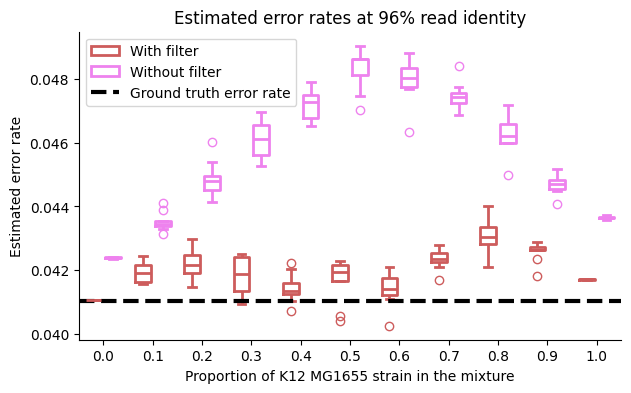

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

i = 2  # Index for 96% identity


result_df_id = result_df[result_df['identity'] == id[i]]
"""
sns.stripplot(
    data=result_df_100x, x="identity", y="error_estimate", hue="with_reference",
    dodge=True, alpha=.2, legend=False,
    palette=["indianred", "goldenrod"],
)
sns.pointplot(
    data=result_df_100x, x="identity", y="error_estimate", hue="with_reference",
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=20, markeredgewidth=3,
    palette=["indianred", "goldenrod"],
)
"""
fig = plt.figure(figsize=(7, 4))
plt.rc('axes.spines', **{'bottom':True, 'left':True, 'right':False, 'top':False})
sns.boxplot(
    data=result_df_id, x="ratio", y="error_estimate", hue="with_filter",
    fill=False, gap=.2,
    linewidth=2,
    flierprops={"marker": "o"},
    palette=["indianred", "violet"],
)
plt.xlabel("Proportion of K12 MG1655 strain in the mixture")
plt.ylabel("Estimated error rate")
plt.title("Estimated error rates at 96% read identity")

# Plot ground truth as a lineplot
ground_truth_error = [1 - np.exp(-l) for l in ground_truth_lambda[::-1]]
#plt.plot(np.arange(len(ground_truth_lambda)), ground_truth_error, color='black', marker='d', linewidth=3, label='Ground truth error rate')
plt.axhline(y=ground_truth_error[::-1][i], color='black', linewidth=3, linestyle='--', label='Ground truth error rate')
plt.legend()
#plt.ylim(0, 0.045)
#plt.tight_layout()
plt.savefig("../../figures/figure2_E.svg")

In [6]:
res = pd.DataFrame({
    'Identity': identity,
    'Ratio': ratio_list,
    'Lambda': lambda_estimates,
    'Beta': beta_estimates,
    'Filter': with_filter
})

In [7]:
res

,Identity,Ratio,Lambda,Beta,Filter
